In [1]:
# import libraries
import numpy as np
from scipy.sparse import diags, csr_matrix
from scipy.sparse.linalg import eigsh
import networkx as nx
import scipy.io as sio
import matplotlib.pyplot as plt
from scipy.io import mmread
from scipy.linalg import cho_factor, cho_solve

# Phase 1: Build the Graph Matrices A, D, L

In [58]:
# read in mtx file - return num_edges, num_vertices
def load_graph(filepath):
    """
    Load a graph from either a true Matrix Market file or a plain edge list.
    Automatically detects format and whether edges are weighted.

    Returns
    -------
    edges        : list of (i, j) tuples
    n_vertices   : int
    edge_weights : dict of {(i,j): weight} or None if unweighted
    """
    with open(filepath, 'r') as f:
        first_line = f.readline().strip()

    if first_line.startswith('%%MatrixMarket'):
        # True .mtx file
        from scipy.io import mmread
        sparse_matrix = mmread(filepath).tocsr()
        n_vertices = sparse_matrix.shape[0]
        coo = sparse_matrix.tocoo()

        edges = []
        edge_weights = {}
        for i, j, v in zip(coo.row, coo.col, coo.data):
            if i < j:
                edges.append((int(i), int(j)))
                if v != 1.0:
                    edge_weights[(int(i), int(j))] = float(v)

        edge_weights = edge_weights if edge_weights else None

    else:
        # Plain edge list — detect 2 vs 3 columns
        edges = []
        edge_weights = {}
        max_vertex = 0
        weighted = None

        with open(filepath, 'r') as f:
            for line in f:
                line = line.strip()
                if not line or line.startswith('%') or line.startswith('#'):
                    continue
                parts = line.split()

                # Detect on first data line
                if weighted is None:
                    weighted = len(parts) == 3
                    print(f"Format detected: {'weighted' if weighted else 'unweighted'} edge list")

                i, j = int(parts[0]) - 1, int(parts[1]) - 1
                if i == j:
                    continue  # skip self-loops
                i, j = min(i, j), max(i, j)
                edges.append((i, j))
                if weighted:
                    edge_weights[(i, j)] = float(parts[2])
                max_vertex = max(max_vertex, i, j)

        edges = list(set(edges))
        n_vertices = max_vertex + 1
        edge_weights = edge_weights if weighted else None

    print(f"Loaded: {filepath}")
    print(f"  Vertices     : {n_vertices}")
    print(f"  Edges        : {len(edges)}")
    print(f"  Edge weights : {'yes' if edge_weights else 'no'}")
    print()

    return edges, n_vertices, edge_weights

In [70]:
def build_graph_matrices(edges, n_vertices, edge_weights=None):
    """
    Build adjacency matrix A, degree matrix D, and graph Laplacian L.
    Handles both weighted and unweighted graphs.

    Parameters
    ----------
    edges        : list of (i, j) tuples
    n_vertices   : int
    edge_weights : dict of {(i,j): weight} or None for unweighted

    Returns
    -------
    A : np.ndarray — adjacency matrix (n x n)
    D : np.ndarray — diagonal degree matrix (n x n)
    L : np.ndarray — graph Laplacian L = D - A (n x n)
    """
    n = n_vertices
    A = np.zeros((n, n))

    for (i, j) in edges:
        # Use weight if provided, otherwise 1
        w = edge_weights.get((i,j), edge_weights.get((j,i), 1.0)) if edge_weights else 1.0
        A[i, j] = w
        A[j, i] = w

    # Degree matrix — row sums of A
    degrees = A.sum(axis=1)
    D = np.diag(degrees)

    # Graph Laplacian
    L = D - A

    return A, D, L

In [72]:
def sanity_check_phase1(A, D, L):
    """
    Run sanity checks on the matrices from Phase 1.
    """
    print("=== Phase 1 Sanity Checks ===")
 
    # Check symmetry
    assert np.allclose(A, A.T), "A is not symmetric!"
    assert np.allclose(L, L.T), "L is not symmetric!"
    print("✓ A and L are symmetric")
 
    # Check L has a zero eigenvalue (since graph is connected)
    eigenvalues = np.linalg.eigvalsh(L)
    min_eig = eigenvalues[0]
    print(f"✓ Smallest eigenvalue of L: {min_eig:.6f} (should be ~0)")
    assert abs(min_eig) < 1e-8, "L does not have a zero eigenvalue!"
 
    # Check L = D - A
    assert np.allclose(L, D - A), "L != D - A!"
    print("✓ L = D - A confirmed")
    print()

# Demo on football.mtx file

In [101]:
# read in the mtx file - store edgelist, num_vertices
edges, n_vertices, edge_weights = load_graph("./baseball (1).mtx")

Loaded: ./baseball (1).mtx
  Vertices     : 30
  Edges        : 300
  Edge weights : yes



In [103]:
# build L,D,A
A, D, L= build_graph_matrices(edges, n_vertices, edge_weights=edge_weights)

In [105]:
sanity_check_phase1(A, D, L)

=== Phase 1 Sanity Checks ===
✓ A and L are symmetric
✓ Smallest eigenvalue of L: 0.000000 (should be ~0)
✓ L = D - A confirmed



# Phase 2: Spectral Shift — Compute λ⁺_min and Build L_sigma

In [80]:
def compute_lambda_min(L, D):
    """
    Compute the smallest positive eigenvalue of D^{-1} L by solving
    the generalized eigenvalue problem: L v = lambda D v.
 
    Parameters
    ----------
    L : np.ndarray — graph Laplacian (n x n)
    D : np.ndarray — degree matrix (n x n)
 
    Returns
    -------
    lambda_min : float — smallest positive eigenvalue of D^{-1} L
    """
 
    # Solve generalized eigenvalue problem L v = lambda D v
    # scipy.linalg.eigh handles the generalized form correctly
    from scipy.linalg import eigh
    eigenvalues, _ = eigh(L, D)
 
    # Filter out the zero eigenvalue (numerical zero = anything < 1e-10)
    positive_eigenvalues = eigenvalues[eigenvalues > 1e-10]
 
    assert len(positive_eigenvalues) > 0, "No positive eigenvalues found!"
 
    lambda_min = positive_eigenvalues[0]
    return lambda_min

In [82]:
def build_shifted_laplacian(L, D, lambda_min, sigma_squared=0.25):
    """
    Build the shifted Laplacian L_sigma = L + sigma^2 * lambda_min * D.
 
    This makes L_sigma symmetric positive definite (SPD) and solvable.
 
    Parameters
    ----------
    L             : np.ndarray — graph Laplacian
    D             : np.ndarray — degree matrix
    lambda_min    : float — smallest positive eigenvalue of D^{-1} L
    sigma_squared : float — shift parameter (default 0.25 as given in project)
 
    Returns
    -------
    L_sigma : np.ndarray — shifted Laplacian (SPD)
    """
 
    L_sigma = L + sigma_squared * lambda_min * D
    return L_sigma

In [18]:
def sanity_check_phase2(L_sigma):
    """
    Run sanity checks on L_sigma from Phase 2.
    """
    print("=== Phase 2 Sanity Checks ===")
 
    # Check symmetry
    assert np.allclose(L_sigma, L_sigma.T), "L_sigma is not symmetric!"
    print("✓ L_sigma is symmetric")
 
    # Check all eigenvalues are positive (SPD condition)
    eigenvalues = np.linalg.eigvalsh(L_sigma)
    min_eig = eigenvalues[0]
    print(f"✓ Smallest eigenvalue of L_sigma: {min_eig:.6f} (should be > 0)")
    assert min_eig > 0, "L_sigma is not SPD — has non-positive eigenvalue!"
    print("✓ L_sigma is SPD (all eigenvalues positive)")
    print()

In [107]:
lambda_min = compute_lambda_min(L,D)

In [109]:
L_sigma = build_shifted_laplacian(L, D, lambda_min, sigma_squared=0.25)

In [111]:
sanity_check_phase2(L_sigma)

=== Phase 2 Sanity Checks ===
✓ L_sigma is symmetric
✓ Smallest eigenvalue of L_sigma: 10.000000 (should be > 0)
✓ L_sigma is SPD (all eigenvalues positive)



# Visualize graph

In [97]:
def visualize_graph(edges, n_vertices, edge_weights=None, title="Graph"):
    """
    Visualize the graph using NetworkX and Matplotlib.
    Handles both unweighted and weighted edges.

    Parameters
    ----------
    edges        : list of (i, j) tuples
    n_vertices   : int
    edge_weights : dict of {(i,j): weight} or None for unweighted
    title        : str
    """
    G = nx.Graph()
    G.add_nodes_from(range(n_vertices))

    if edge_weights:
        for (i, j) in edges:
            w = edge_weights.get((i,j), edge_weights.get((j,i), 1.0))
            G.add_edge(i, j, weight=w)
    else:
        G.add_edges_from(edges)

    pos = nx.spring_layout(G, seed=42)
    plt.figure(figsize=(15, 15))

    # Draw nodes
    nx.draw_networkx_nodes(G, pos, node_color="#1a3a5c", node_size=600)
    nx.draw_networkx_labels(G, pos, font_color="white", font_size=9)

    if edge_weights:
        weights = [G[i][j]['weight'] for i,j in G.edges()]
        edges_drawn = nx.draw_networkx_edges(G, pos, edge_color=weights,
                                              edge_cmap=plt.cm.Blues, width=2,
                                              edge_vmin=min(weights),
                                              edge_vmax=max(weights))
        edge_labels = {(i,j): f"{G[i][j]['weight']:.2f}" for i,j in G.edges()}
        nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=7)

        sm = plt.cm.ScalarMappable(cmap=plt.cm.Blues,
                                   norm=plt.Normalize(vmin=min(weights), vmax=max(weights)))
        plt.colorbar(sm, ax=plt.gca(), label="Edge Weight")
    else:
        nx.draw_networkx_edges(G, pos, edge_color="black", width=2)

    plt.title(title)
    plt.axis("off")
    plt.tight_layout()
    plt.show()

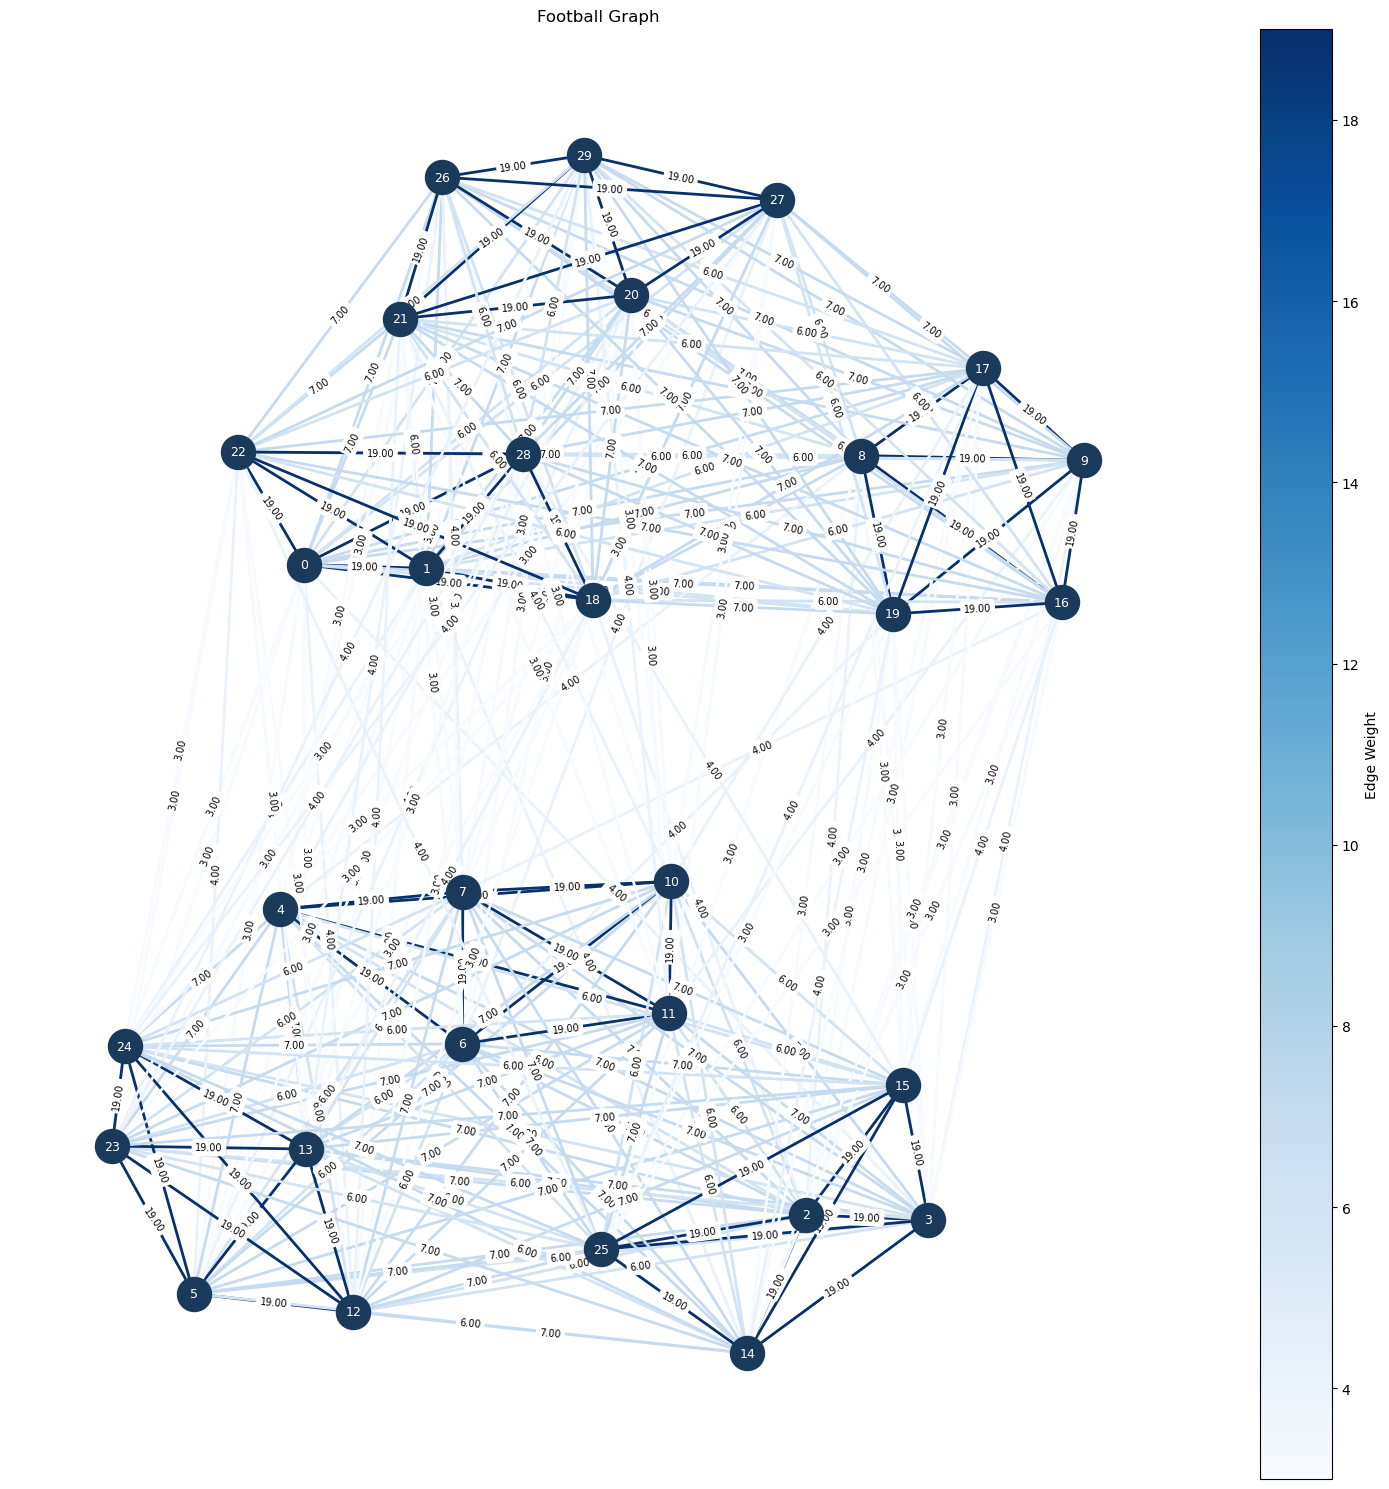

In [113]:
visualize_graph(edges, n_vertices, edge_weights=edge_weights, title="Football Graph")

# prettier viz

Loaded: ./baseball (1).mtx
  Vertices     : 30
  Edges        : 300
  Edge weights : yes



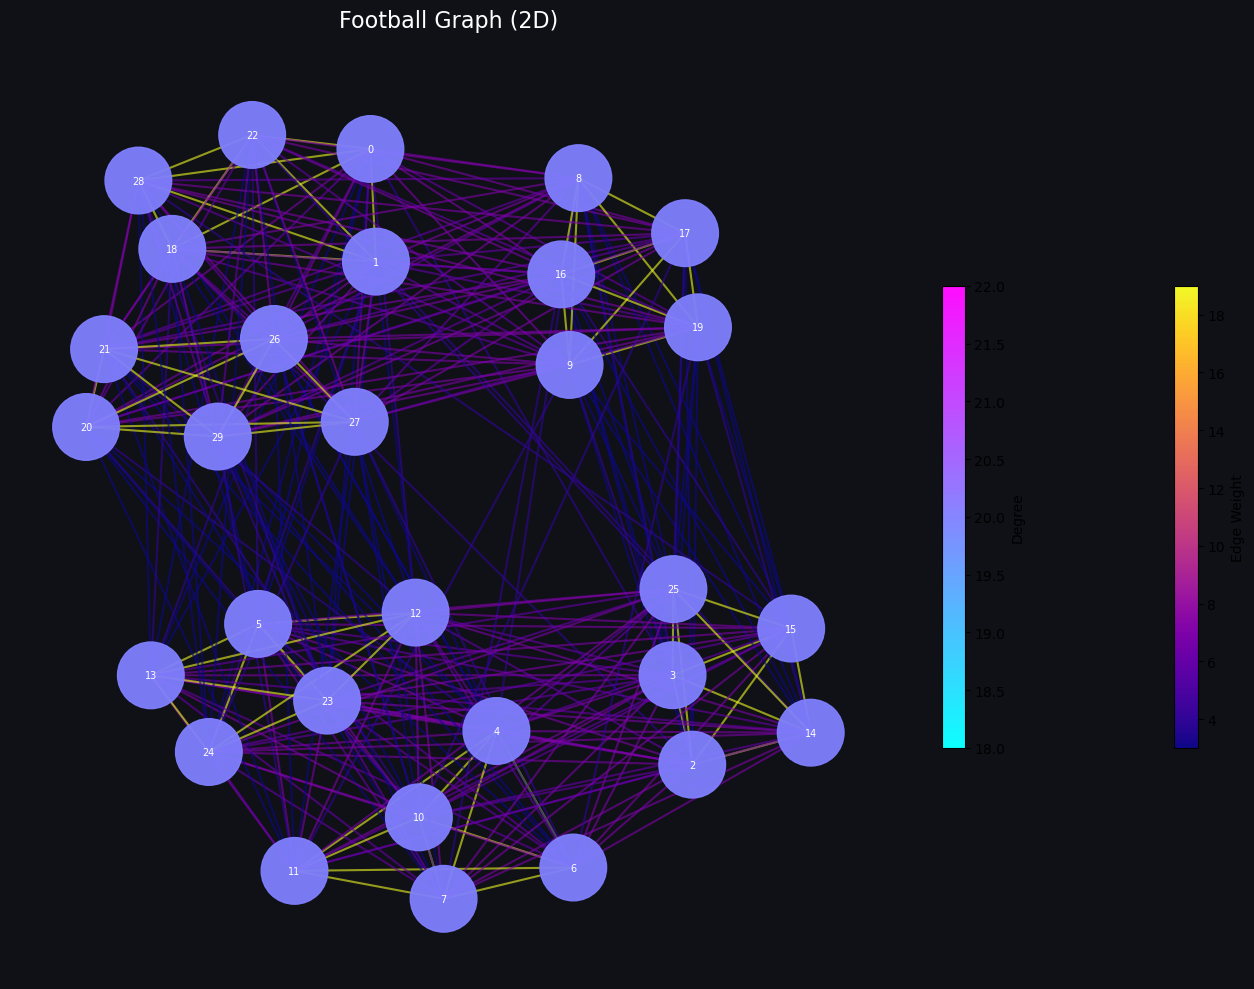

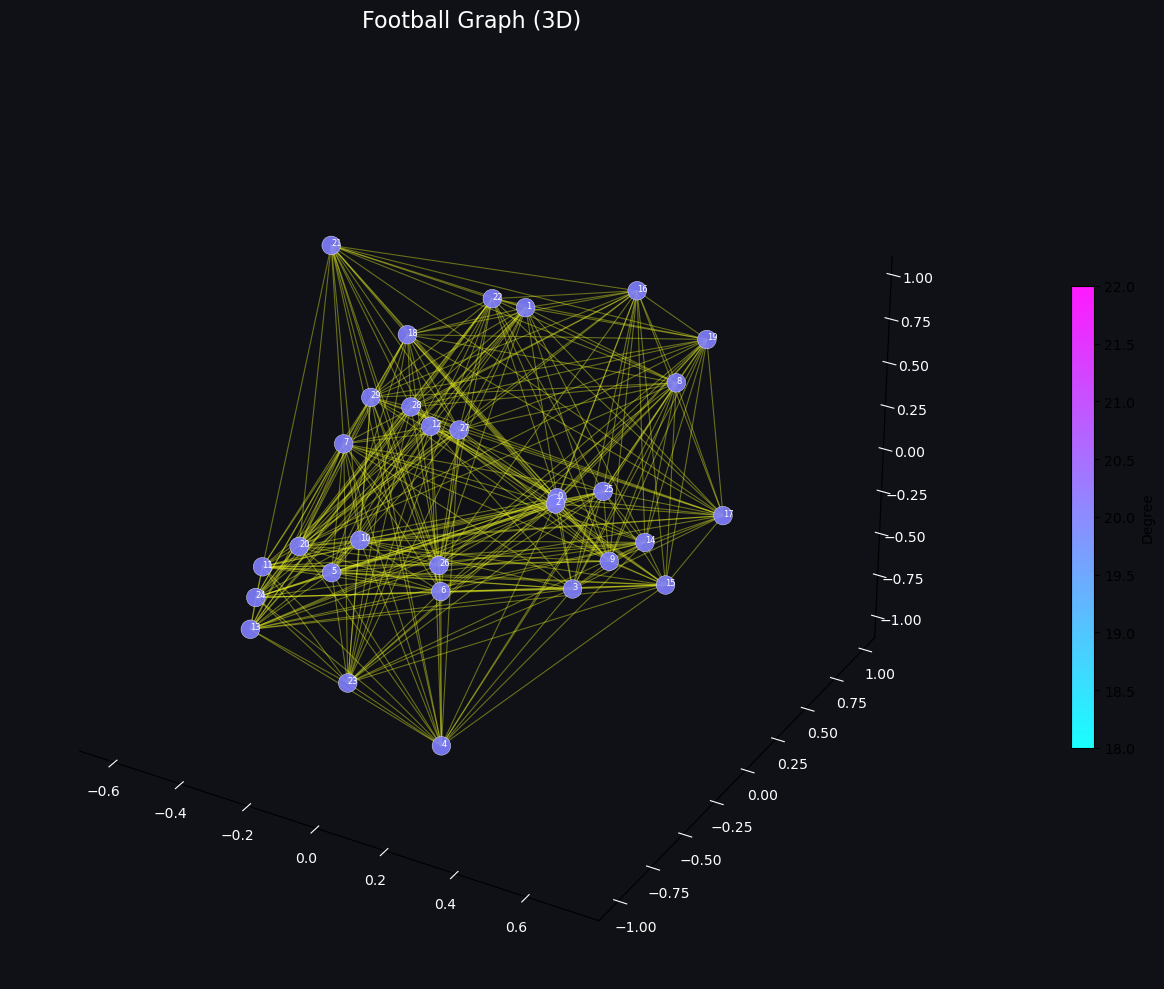

In [150]:
import networkx as nx
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

def visualize_graph_2d(edges, n_vertices, edge_weights=None, title="Graph"):
    """
    Pretty 2D graph visualization.
    """
    G = nx.Graph()
    G.add_nodes_from(range(n_vertices))

    if edge_weights:
        for (i, j) in edges:
            w = edge_weights.get((i,j), edge_weights.get((j,i), 1.0))
            G.add_edge(i, j, weight=w)
    else:
        G.add_edges_from(edges)

    pos = nx.spring_layout(G, seed=42, k=2)

    # degree-based node sizing — higher degree = bigger node
    degrees = dict(G.degree())
    node_sizes = [300 + degrees[v] * 100 for v in G.nodes()]

    # degree-based node coloring
    node_colors = [degrees[v] for v in G.nodes()]

    fig, ax = plt.subplots(figsize=(14, 10))
    fig.patch.set_facecolor("#0f1117")
    ax.set_facecolor("#0f1117")

    # edges
    if edge_weights:
        weights = [G[i][j]['weight'] for i,j in G.edges()]
        nx.draw_networkx_edges(G, pos, ax=ax, edge_color=weights,
                               edge_cmap=plt.cm.plasma, width=1.5,
                               alpha=0.6, edge_vmin=min(weights), edge_vmax=max(weights))
        sm = plt.cm.ScalarMappable(cmap=plt.cm.plasma,
                                   norm=plt.Normalize(vmin=min(weights), vmax=max(weights)))
        plt.colorbar(sm, ax=ax, label="Edge Weight", shrink=0.5)
    else:
        nx.draw_networkx_edges(G, pos, ax=ax, edge_color="#ffffff", width=0.8, alpha=0.3)

    # nodes
    nc = nx.draw_networkx_nodes(G, pos, ax=ax, node_size=node_sizes,
                                 node_color=node_colors, cmap=plt.cm.cool, alpha=0.95)
    plt.colorbar(nc, ax=ax, label="Degree", shrink=0.5)

    # labels only if small graph
    if n_vertices <= 50:
        nx.draw_networkx_labels(G, pos, ax=ax, font_color="white", font_size=7)

    ax.set_title(title, color="white", fontsize=16, pad=20)
    ax.axis("off")
    plt.tight_layout()
    plt.show()


def visualize_graph_3d(edges, n_vertices, edge_weights=None, title="Graph (3D)"):
    """
    3D graph visualization using spring layout projected into 3D.
    """
    G = nx.Graph()
    G.add_nodes_from(range(n_vertices))

    if edge_weights:
        for (i, j) in edges:
            w = edge_weights.get((i,j), edge_weights.get((j,i), 1.0))
            G.add_edge(i, j, weight=w)
    else:
        G.add_edges_from(edges)

    # 3D positions — use spring layout + random z coordinate
    pos_2d = nx.spring_layout(G, seed=42, k=2)
    pos_3d = {v: np.array([pos_2d[v][0], pos_2d[v][1], np.random.uniform(-1, 1)])
              for v in G.nodes()}

    degrees = dict(G.degree())

    fig = plt.figure(figsize=(14, 10))
    fig.patch.set_facecolor("#0f1117")
    ax = fig.add_subplot(111, projection='3d')
    ax.set_facecolor("#0f1117")

    # draw edges
    for (i, j) in G.edges():
        x = [pos_3d[i][0], pos_3d[j][0]]
        y = [pos_3d[i][1], pos_3d[j][1]]
        z = [pos_3d[i][2], pos_3d[j][2]]
        if edge_weights:
            w = G[i][j]['weight']
            ax.plot(x, y, z, color=plt.cm.plasma(w), alpha=0.4, linewidth=0.8)
        else:
            ax.plot(x, y, z, color="white", alpha=0.2, linewidth=0.6)

    # draw nodes
    xs = [pos_3d[v][0] for v in G.nodes()]
    ys = [pos_3d[v][1] for v in G.nodes()]
    zs = [pos_3d[v][2] for v in G.nodes()]
    node_colors = [degrees[v] for v in G.nodes()]
    node_sizes = [20 + degrees[v] * 8 for v in G.nodes()]

    sc = ax.scatter(xs, ys, zs, c=node_colors, cmap=plt.cm.cool,
                    s=node_sizes, alpha=0.9, edgecolors="white", linewidths=0.3)
    plt.colorbar(sc, ax=ax, label="Degree", shrink=0.5, pad=0.1)

    # labels only if small graph
    if n_vertices <= 30:
        for v in G.nodes():
            ax.text(pos_3d[v][0], pos_3d[v][1], pos_3d[v][2], str(v),
                    color='white', fontsize=6)

    ax.set_title(title, color="white", fontsize=16, pad=20)
    ax.grid(False)
    ax.xaxis.pane.fill = False
    ax.yaxis.pane.fill = False
    ax.zaxis.pane.fill = False
    ax.xaxis.pane.set_edgecolor('#0f1117')
    ax.yaxis.pane.set_edgecolor('#0f1117')
    ax.zaxis.pane.set_edgecolor('#0f1117')
    ax.tick_params(colors='white')
    plt.tight_layout()
    plt.show()


# =============================================================================
# DEMO
# =============================================================================

if __name__ == "__main__":
    # swap in your actual edges and n_vertices
    edges, n_vertices, edge_weights = load_graph("./baseball (1).mtx")

    visualize_graph_2d(edges, n_vertices, edge_weights=edge_weights, title="Football Graph (2D)")
    visualize_graph_3d(edges, n_vertices, edge_weights=edge_weights, title="Football Graph (3D)")

# Phase 3: White Noise sampling pipeline

## The What
### 3a- Draw edge noise
- For every edge, draw a random number from N(0,1).
- These numbers are going to be all independent - which is the "white" in white noise. The numbers picked for 2 given edges have no correlation with each other so far.

### 3b - Map noise to vertices
- add up the random noise of each edge that's incident to a vertex (going into and out of the vertex)
- this makes their f values correlated becuase 2 neighboring vertices share atleast one common edge.
- the more common edges 2 vertices have, more correlated their f values are

### 3c - Solve for correlated field u
- the noise is still very uncorrelated for neighboring vertices but in practice, neighboring vertices have correated flow
- for this, use L_sigma and get u values so that we get more correlated values for vertices

In [ ]:
# =============================================================================
# PHASE 3: White Noise Sampling Pipeline
# =============================================================================

def build_incidence_matrix(edges, n_vertices):
    """
    Build the signed vertex-edge incidence matrix B (n x m).
    B[i, e] = +1 if vertex i is the first endpoint of edge e
    B[j, e] = -1 if vertex j is the second endpoint of edge e

    Parameters
    ----------
    edges      : list of (i, j) tuples
    n_vertices : int

    Returns
    -------
    B : np.ndarray of shape (n_vertices, n_edges)
    """
    n = n_vertices
    m = len(edges)
    B = np.zeros((n, m))

    for idx, (i, j) in enumerate(edges):
        B[i, idx] =  1
        B[j, idx] = -1

    return B


def draw_edge_noise(n_edges):
    """
    STEP 3a: Draw independent N(0,1) noise for every edge.

    Parameters
    ----------
    n_edges : int

    Returns
    -------
    w : np.ndarray of shape (n_edges,)
    """
    w = np.random.randn(n_edges)
    return w


def map_noise_to_vertices(B, w):
    """
    STEP 3b: Map edge noise to vertices.
    f_i = sum of w_e over all edges touching vertex i.
    In matrix form: f = B @ w

    Parameters
    ----------
    B : np.ndarray (n_vertices x n_edges)
    w : np.ndarray (n_edges,)

    Returns
    -------
    f : np.ndarray (n_vertices,)
    """
    f = B @ w
    return f


def solve_for_u(L_sigma, lambda_min, f, cho_cache=None):
    """
    STEP 3c: Solve L_sigma u = lambda_min * f.
    Cholesky factorization is computed once and reused every MC step
    since L_sigma is fixed across all samples.

    Parameters
    ----------
    L_sigma    : np.ndarray (n x n) — fixed across all MC steps
    lambda_min : float
    f          : np.ndarray (n,)
    cho_cache  : precomputed Cholesky factorization (reuse across steps)

    Returns
    -------
    u         : np.ndarray (n,)
    cho_cache : pass this back in on the next MC step
    """
    if cho_cache is None:
        cho_cache = cho_factor(L_sigma)

    rhs = lambda_min * f
    u = cho_solve(cho_cache, rhs)

    return u, cho_cache

In [139]:
# function to run entire phase 3 after building incidence matrix B
def run_phase3(L_sigma, lambda_min, edges, n_vertices, n_samples=3):
    B = build_incidence_matrix(edges, n_vertices)
    cho_cache = None
    samples_u = []

    print(f"✓ Phase 3: Running {n_samples} Monte Carlo samples")
    print()

    for i in range(n_samples):
        # 3a: draw edge noise
        w = np.random.randn(len(edges))

        # 3b: map to vertices
        f = B @ w

        # 3c: solve for correlated field
        if cho_cache is None:
            cho_cache = cho_factor(L_sigma)
        u = cho_solve(cho_cache, lambda_min * f)

        samples_u.append(u)

        print(f"  Sample {i+1}:")
        print(f"    w (edge noise)      : {np.round(w[:5], 3)} ...")
        print(f"    f (vertex sums)     : {np.round(f[:5], 3)} ...")
        print(f"    u (correlated field): {np.round(u[:5], 3)} ...")
        print()
        print("    Neighbor smoothing check (f diff vs u diff):")
        for (vi, vj) in edges[:3]:  # show first 3 edges
            print(f"      edge ({vi},{vj}): f diff = {abs(f[vi]-f[vj]):.3f}  |  u diff = {abs(u[vi]-u[vj]):.3f}")
        print()

    return samples_u

In [129]:
# =============================================================================
# DEMO
# =============================================================================

if __name__ == "__main__":

    # Paste your edges and n_vertices from Phase 1 here
    n_vertices = 5
    edges = [
        (0, 1),
        (0, 2),
        (1, 2),
        (1, 3),
        (2, 4),
        (3, 4),
    ]

    # Rebuild L_sigma and lambda_min from Phases 1 & 2
    from scipy.linalg import eigh

    A = np.zeros((n_vertices, n_vertices))
    for (i, j) in edges:
        A[i, j] = 1
        A[j, i] = 1
    degrees = A.sum(axis=1)
    D = np.diag(degrees)
    L = D - A
    eigenvalues, _ = eigh(L, D)
    lambda_min = eigenvalues[eigenvalues > 1e-10][0]
    L_sigma = L + 0.25 * lambda_min * D

    # Build incidence matrix once
    B = build_incidence_matrix(edges, n_vertices)

    # Cholesky factorize once — reuse every MC step
    cho_cache = None

    print("Running 3 Monte Carlo samples:\n")
    np.random.seed(42)

    for i in range(3):
        w = draw_edge_noise(len(edges))        # 3a
        f = map_noise_to_vertices(B, w)         # 3b
        u, cho_cache = solve_for_u(L_sigma, lambda_min, f, cho_cache)  # 3c

        print(f"Sample {i+1}:")
        print(f"  w (edge noise)      : {np.round(w, 3)}")
        print(f"  f (vertex sums)     : {np.round(f, 3)}")
        print(f"  u (correlated field): {np.round(u, 3)}")
        print()


# sanity check
print("Neighbor differences in f vs u:")
for (i, j) in edges:
    print(f"  edge ({i},{j}): f diff = {abs(f[i]-f[j]):.3f}  |  u diff = {abs(u[i]-u[j]):.3f}")

Running 3 Monte Carlo samples:

Sample 1:
  w (edge noise)      : [ 0.497 -0.138  0.648  1.523 -0.234 -0.234]
  f (vertex sums)     : [ 0.358  1.674 -0.744 -1.757  0.468]
  u (correlated field): [ 0.189  0.24  -0.038 -0.427 -0.065]

Sample 2:
  w (edge noise)      : [ 1.579  0.767 -0.469  0.543 -0.463 -0.466]
  f (vertex sums)     : [ 2.347 -1.506 -0.761 -1.008  0.929]
  u (correlated field): [ 0.57  -0.223 -0.013 -0.333  0.117]

Sample 3:
  w (edge noise)      : [ 0.242 -1.913 -1.725 -0.562 -1.013  0.314]
  f (vertex sums)     : [-1.671 -2.529  2.625  0.877  0.699]
  u (correlated field): [-0.527 -0.463  0.347  0.247  0.454]

Neighbor differences in f vs u:
  edge (0,1): f diff = 0.858  |  u diff = 0.064
  edge (0,2): f diff = 4.297  |  u diff = 0.874
  edge (1,2): f diff = 5.155  |  u diff = 0.810
  edge (1,3): f diff = 3.406  |  u diff = 0.709
  edge (2,4): f diff = 1.927  |  u diff = 0.107
  edge (3,4): f diff = 0.178  |  u diff = 0.207


### sanity check
- to see if smoothening worked, f values would be jagged - big jumps between consecutive values
- u would be smooth - relatively smaller jumps than f
- the sanity check code shows the difference between f and u values

# Demo from phase 1 to 3

In [141]:
# =============================================================================
# RUN FULL DEMO
# =============================================================================

if __name__ == "__main__":

    np.random.seed(42)

    # --- Change this to your actual .mtx file path ---
    filepath = "./baseball (1).mtx"

    # Phase 1
    edges, n_vertices, edge_weights = load_graph(filepath)
    A, D, L = build_graph_matrices(edges, n_vertices, edge_weights)

    # Phase 2
    lambda_min = compute_lambda_min(L, D)
    L_sigma    = build_shifted_laplacian(L, D, lambda_min)

    # Phase 3
    samples_u = run_phase3(L_sigma, lambda_min, edges, n_vertices, n_samples=3)

Loaded: ./baseball (1).mtx
  Vertices     : 30
  Edges        : 300
  Edge weights : yes

✓ Phase 3: Running 3 Monte Carlo samples

  Sample 1:
    w (edge noise)      : [ 0.497 -0.138  0.648  1.523 -0.234] ...
    f (vertex sums)     : [-3.426 -6.013 -1.312  2.484 -3.25 ] ...
    u (correlated field): [-0.006 -0.009 -0.001  0.004 -0.003] ...

    Neighbor smoothing check (f diff vs u diff):
      edge (0,1): f diff = 2.587  |  u diff = 0.003
      edge (0,3): f diff = 5.910  |  u diff = 0.010
      edge (0,5): f diff = 0.289  |  u diff = 0.002

  Sample 2:
    w (edge noise)      : [-0.829 -0.56   0.747  0.61  -0.021] ...
    f (vertex sums)     : [ 5.508  2.361 -3.953  7.683  2.392] ...
    u (correlated field): [ 0.007  0.003 -0.002  0.013  0.007] ...

    Neighbor smoothing check (f diff vs u diff):
      edge (0,1): f diff = 3.148  |  u diff = 0.004
      edge (0,3): f diff = 2.175  |  u diff = 0.006
      edge (0,5): f diff = 9.548  |  u diff = 0.010

  Sample 3:
    w (edge nois